In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from scipy.signal import find_peaks
import subprocess
import yt

def read_athinput(path):
    params = {}
    section = None
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            m = re.match(r'^<(\w+)>$', line)
            if m:
                section = m.group(1)
                if section != 'comment':
                    params[section] = {}
                continue
            if section and section != 'comment' and '=' in line:
                key, _, rest = line.partition('=')
                value = rest.split('#')[0].strip()
                key = key.strip()
                try:
                    value = int(value)
                except ValueError:
                    try:
                        value = float(value)
                    except ValueError:
                        pass
                params[section][key] = value
    return params


In [2]:
inp = read_athinput('/scratch/aripoll/athena/inputs/mhd/athinput.1d_blast')
print(inp)

star_radius  = inp['problem']['star_radius']
cs_factor    = inp['problem']['cs_factor']
bomb_radius  = inp['problem']['bomb_radius']
bomb_p_ratio = inp['problem']['bomb_p_ratio']
vy_bulk      = inp['problem'].get('vy_bulk', 0.0)
Gam_bulk     = inp['problem'].get('Gam_bulk', 1.0)
gamma_eos    = inp['hydro']['gamma']

if vy_bulk != 0.0:
    Gam_y = 1.0 / np.sqrt(max(1.0 - vy_bulk**2, 1e-12))
elif Gam_bulk > 1.0:
    Gam_y   = Gam_bulk
    vy_bulk = np.sqrt(1.0 - 1.0 / Gam_bulk**2)
else:
    Gam_y = 1.0

print(f'vy_bulk = {vy_bulk:.4f}  (Gam_y = {Gam_y:.3f})')
print(f'bomb: x < {bomb_radius}, pressure x{bomb_p_ratio:.0e}')


{'job': {'problem_id': '1d_blast'}, 'output1': {'file_type': 'hdf5', 'data_format': 'double', 'variable': 'prim,cons', 'dt': 0.01}, 'output2': {'file_type': 'hst', 'dt': 0.001}, 'time': {'cfl_number': 0.25, 'nlim': -1, 'tlim': 10.0, 'integrator': 'vl2', 'xorder': 2, 'ncycle_out': 100}, 'mesh': {'nx1': 2048, 'x1min': 0.0, 'x1max': 2.0, 'ix1_bc': 'reflecting', 'ox1_bc': 'outflow', 'nx2': 1, 'x2min': -0.5, 'x2max': 0.5, 'ix2_bc': 'periodic', 'ox2_bc': 'periodic', 'nx3': 1, 'x3min': -0.5, 'x3max': 0.5, 'ix3_bc': 'periodic', 'ox3_bc': 'periodic'}, 'meshblock': {'nx1': 8, 'nx2': 1, 'nx3': 1}, 'hydro': {'gamma': 1.3333333333333333, 'dfloor': 1e-28, 'pfloor': 1e-34}, 'problem': {'star_radius': 1.0, 'poly_index': 3.0, 'poly_csv_path': '/scratch/aripoll/athena/polytrope_n3.00.csv', 'cs_factor': 1e-06, 'bomb_radius': 0.1, 'bomb_p_ratio': 10000.0, 'ambient_rho': 1e-25, 'ambient_p': 1e-25, 'vy_bulk': 0, 'Gam_bulk': 1, 'thr': 0.5}}
vy_bulk = 0.0000  (Gam_y = 1.000)
bomb: x < 0.1, pressure x1e+04


/tmp/ipykernel_2878000/2135255113.py:5: RuntimeWarning: invalid value encountered in divide
  S_poly   = P_poly / rho_poly**gamma_eos


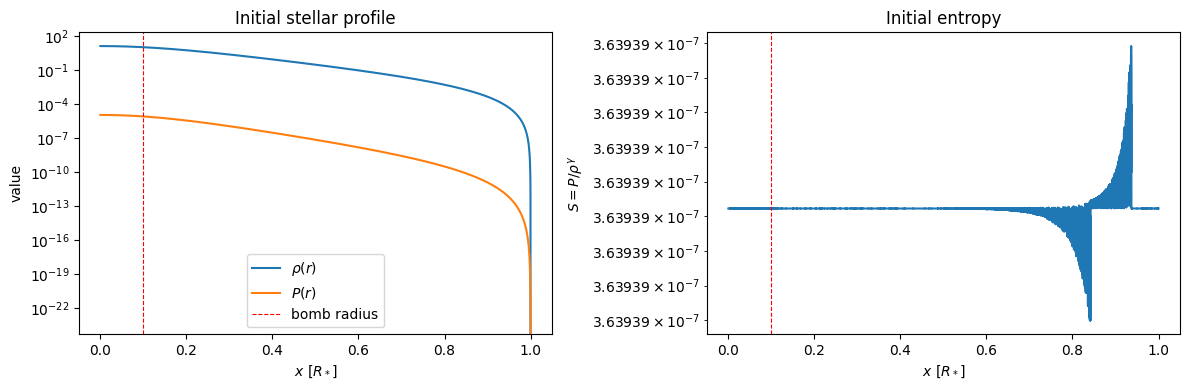

In [3]:
poly = pd.read_csv(inp['problem']['poly_csv_path'])
r_poly   = poly['r'].values
rho_poly = poly['rho'].values
P_poly   = poly['P'].values * cs_factor
S_poly   = P_poly / rho_poly**gamma_eos

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(r_poly, rho_poly, label=r'$\rho(r)$')
axes[0].semilogy(r_poly, P_poly,   label=r'$P(r)$')
axes[0].axvline(bomb_radius, color='red', ls='--', lw=0.8, label='bomb radius')
axes[0].set_xlabel(r'$x\ [R_*]$'); axes[0].set_ylabel('value')
axes[0].legend(); axes[0].set_title('Initial stellar profile')
axes[1].semilogy(r_poly, S_poly)
axes[1].axvline(bomb_radius, color='red', ls='--', lw=0.8)
axes[1].set_xlabel(r'$x\ [R_*]$'); axes[1].set_ylabel(r'$S = P/\rho^\gamma$')
axes[1].set_title('Initial entropy')
plt.tight_layout(); plt.show()


In [4]:
ds = yt.load('/scratch/aripoll/athena_out/outputs/1d_blast.out1.00000.athdf')
print(ds.derived_field_list)

yt : [WARNING  ] 2026-05-28 14:59:36,719 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 14:59:36,720 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 14:59:36,720 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 14:59:36,720 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 14:59:36,759 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-28 14:59:36,760 Parameters: domain_dimensions         = [2048    1    1]
yt : [INFO     ] 2026-05-28 14:59:36,760 Parameters: domain_left_edge          = [ 0.  -0.5 -0.5]
yt : [INFO     ] 2026-05-28 14:59:36,760 Parameters: domain_right_edge         = [2.  0.5 0.5]
yt : [INFO     ] 2026-05-28 14:59:36,761 Parameters: cosmological_simulation   = 0


[('athena_pp', 'Etot'), ('athena_pp', 'cell_volume'), ('athena_pp', 'dens'), ('athena_pp', 'dr'), ('athena_pp', 'dtheta'), ('athena_pp', 'dz'), ('athena_pp', 'mom1'), ('athena_pp', 'mom2'), ('athena_pp', 'mom3'), ('athena_pp', 'path_element_r'), ('athena_pp', 'path_element_theta'), ('athena_pp', 'path_element_z'), ('athena_pp', 'press'), ('athena_pp', 'r'), ('athena_pp', 'r0'), ('athena_pp', 'rho'), ('athena_pp', 's0'), ('athena_pp', 'theta'), ('athena_pp', 'vel1'), ('athena_pp', 'vel2'), ('athena_pp', 'vel3'), ('athena_pp', 'volume'), ('athena_pp', 'z'), ('gas', 'averaged_density'), ('gas', 'cell_mass'), ('gas', 'cell_volume'), ('gas', 'density'), ('gas', 'density_gradient_magnitude'), ('gas', 'density_gradient_r'), ('gas', 'density_gradient_theta'), ('gas', 'density_gradient_z'), ('gas', 'dr'), ('gas', 'dtheta'), ('gas', 'dynamical_time'), ('gas', 'dz'), ('gas', 'four_velocity_magnitude'), ('gas', 'four_velocity_r'), ('gas', 'four_velocity_t'), ('gas', 'four_velocity_theta'), ('gas',

yt : [WARNING  ] 2026-05-28 14:59:36,987 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 14:59:36,988 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 14:59:36,988 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 14:59:36,988 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 14:59:37,014 Parameters: current_time              = 2.000244140625
yt : [INFO     ] 2026-05-28 14:59:37,014 Parameters: domain_dimensions         = [2048    1    1]
yt : [INFO     ] 2026-05-28 14:59:37,014 Parameters: domain_left_edge          = [ 0.  -0.5 -0.5]
yt : [INFO     ] 2026-05-28 14:59:37,015 Parameters: domain_right_edge         = [2.  0.5 0.5]
yt : [INFO     ] 2026-05-28 14:59:37,015 Parameters: cosmological_simulation   = 0


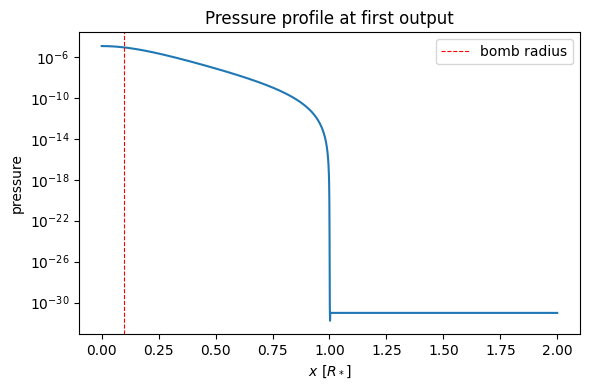

In [5]:
ds = yt.load('/scratch/aripoll/athena_out/outputs/1d_blast.out1.00200.athdf')
ray = ds.ortho_ray(0, (0.0, 0.0))
ray_df = ray.to_dataframe([('index', 'r'), ('gas', 'pressure')])
ray_df = ray_df.sort_values('r').reset_index(drop=True)
plt.figure(figsize=(6, 4))
plt.plot(ray_df['r'], ray_df['pressure'])
plt.xlabel(r'$x\ [R_*]$'); plt.ylabel('pressure')
plt.title('Pressure profile at first output')
plt.yscale('log')
plt.axvline(bomb_radius, color='red', ls='--', lw=0.8, label='bomb radius')
plt.legend(); plt.tight_layout(); plt.show()

In [6]:
# All derived quantities computed as plain numpy — no yt field registration.

OUTDIR = Path('/scratch/aripoll/athena_out/outputs')

def get_profile(ds):
    y0 = float(ds.domain_left_edge[1] + ds.domain_right_edge[1]) / 2.0
    z0 = float(ds.domain_left_edge[2] + ds.domain_right_edge[2]) / 2.0
    ray = ds.ortho_ray(0, (y0, z0))

    x     = np.array(ray[('index', 'r')].in_units('code_length'))
    rho   = np.array(ray[('athena_pp', 'rho')])
    press = np.array(ray[('athena_pp', 'press')])
    vel1  = np.array(ray[('athena_pp', 'vel1')])
    vel2  = np.array(ray[('athena_pp', 'vel2')])
    vel3  = np.array(ray[('athena_pp', 'vel3')])

    v2       = np.clip(vel1**2 + vel2**2 + vel3**2, 0.0, 1.0 - 1e-12)
    gamma    = 1.0 / np.sqrt(1.0 - v2)
    enthalpy = 1.0 + (gamma_eos / (gamma_eos - 1.0)) * press / np.maximum(rho, 1e-30)
    entropy  = press / np.maximum(rho, 1e-60)**gamma_eos

    idx = np.argsort(x)
    return {
        'x':             x[idx],
        'rho':           rho[idx],
        'press':         press[idx],
        'vel1':          vel1[idx],
        'vel2':          vel2[idx],
        'vel3':          vel3[idx],
        'lorentz_gamma': gamma[idx],
        'enthalpy':      enthalpy[idx],
        'entropy':       entropy[idx],
    }


yt : [WARNING  ] 2026-05-28 14:59:37,788 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 14:59:37,789 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 14:59:37,789 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 14:59:37,789 Assuming 1.0 = 1.0 K


yt : [INFO     ] 2026-05-28 14:59:37,814 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-28 14:59:37,815 Parameters: domain_dimensions         = [2048    1    1]
yt : [INFO     ] 2026-05-28 14:59:37,815 Parameters: domain_left_edge          = [ 0.  -0.5 -0.5]
yt : [INFO     ] 2026-05-28 14:59:37,815 Parameters: domain_right_edge         = [2.  0.5 0.5]
yt : [INFO     ] 2026-05-28 14:59:37,815 Parameters: cosmological_simulation   = 0


t = 0.0000
Native fields: [('athena_pp', 'Etot'), ('athena_pp', 'dens'), ('athena_pp', 'mom1'), ('athena_pp', 'mom2'), ('athena_pp', 'mom3'), ('athena_pp', 'press'), ('athena_pp', 'r0'), ('athena_pp', 'rho'), ('athena_pp', 's0'), ('athena_pp', 'vel1'), ('athena_pp', 'vel2'), ('athena_pp', 'vel3')]


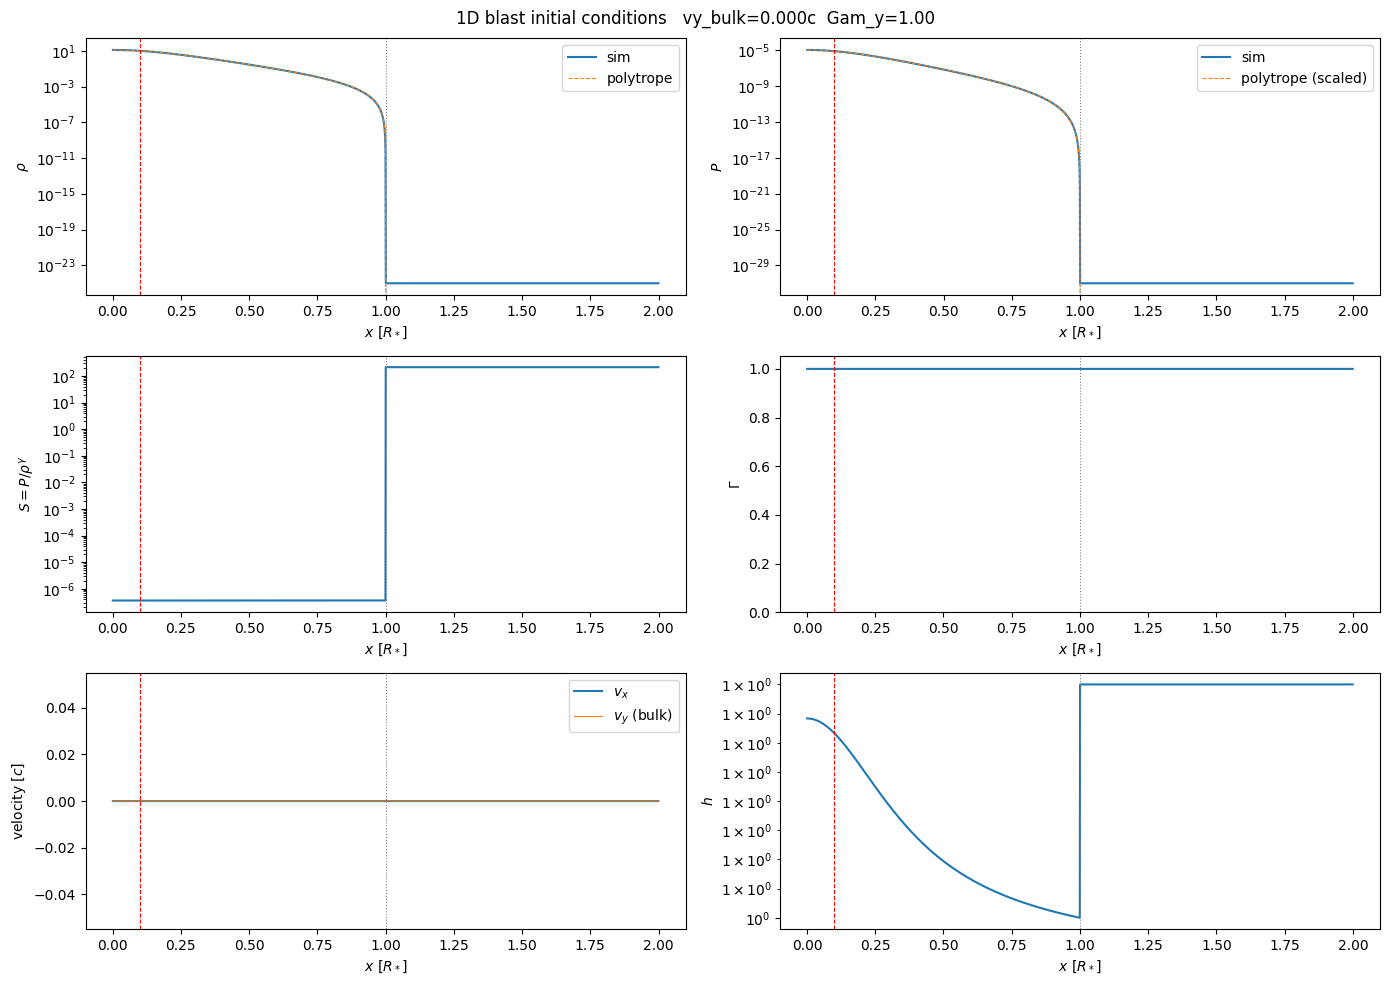

In [7]:
ds0 = yt.load(str(OUTDIR / '1d_blast.out1.00000.athdf'))
print(f't = {float(ds0.current_time):.4f}')
print('Native fields:', ds0.field_list)

d = get_profile(ds0)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

axes[0].semilogy(d['x'], d['rho'],   label='sim')
axes[0].semilogy(r_poly, rho_poly, '--', label='polytrope', lw=0.8)
axes[0].set_ylabel(r'$\rho$'); axes[0].legend()

axes[1].semilogy(d['x'], d['press'],  label='sim')
axes[1].semilogy(r_poly, P_poly, '--', label='polytrope (scaled)', lw=0.8)
axes[1].set_ylabel(r'$P$'); axes[1].legend()

axes[2].semilogy(d['x'], d['entropy'])
axes[2].set_ylabel(r'$S = P/\rho^\gamma$')

axes[3].plot(d['x'], d['lorentz_gamma'])
axes[3].set_ylabel(r'$\Gamma$'); axes[3].set_ylim(bottom=0)

axes[4].plot(d['x'], d['vel1'], label=r'$v_x$')
axes[4].plot(d['x'], d['vel2'], label=r'$v_y$ (bulk)', lw=0.8)
axes[4].set_ylabel(r'velocity $[c]$'); axes[4].legend()

axes[5].semilogy(d['x'], d['enthalpy'])
axes[5].set_ylabel(r'$h$')

for ax in axes:
    ax.set_xlabel(r'$x\ [R_*]$')
    ax.axvline(star_radius, color='grey', ls=':', lw=0.8)
    ax.axvline(bomb_radius, color='red',  ls='--', lw=0.8)

fig.suptitle(f'1D blast initial conditions   vy_bulk={vy_bulk:.3f}c  Gam_y={Gam_y:.2f}')
plt.tight_layout(); plt.show()


yt : [WARNING  ] 2026-05-28 14:59:38,735 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 14:59:38,735 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 14:59:38,736 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 14:59:38,736 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 14:59:38,758 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-28 14:59:38,758 Parameters: domain_dimensions         = [2048    1    1]
yt : [INFO     ] 2026-05-28 14:59:38,758 Parameters: domain_left_edge          = [ 0.  -0.5 -0.5]
yt : [INFO     ] 2026-05-28 14:59:38,758 Parameters: domain_right_edge         = [2.  0.5 0.5]
yt : [INFO     ] 2026-05-28 14:59:38,759 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-05-28 14:59:38,861 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 14:59:38,861 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 14:59:38,861 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 14:59:38,862 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 14:59:38,883 Pa

Total snapshots: 1001


yt : [WARNING  ] 2026-05-28 14:59:38,984 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 14:59:38,985 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 14:59:38,985 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 14:59:38,985 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 14:59:39,007 Parameters: current_time              = 2.85009765625
yt : [INFO     ] 2026-05-28 14:59:39,007 Parameters: domain_dimensions         = [2048    1    1]
yt : [INFO     ] 2026-05-28 14:59:39,007 Parameters: domain_left_edge          = [ 0.  -0.5 -0.5]
yt : [INFO     ] 2026-05-28 14:59:39,008 Parameters: domain_right_edge         = [2.  0.5 0.5]
yt : [INFO     ] 2026-05-28 14:59:39,008 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-05-28 14:59:39,110 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 14:59:39,110 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 14:59:39,110 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 14:59:39,111 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 14:59

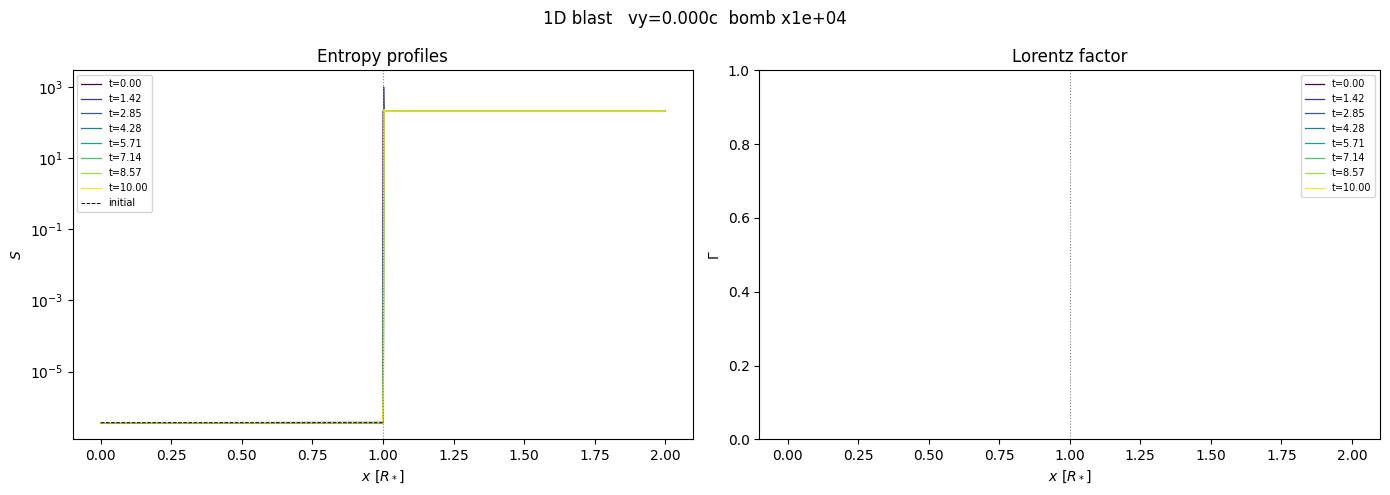

In [8]:
ts = yt.load(str(OUTDIR / '1d_blast.out1.*.athdf'))
print(f'Total snapshots: {len(ts)}')

n_show = 8
indices = np.linspace(0, len(ts)-1, n_show, dtype=int)
colors  = cm.viridis(np.linspace(0, 1, n_show))

fig, (ax_S, ax_G) = plt.subplots(1, 2, figsize=(14, 5))
for color, idx in zip(colors, indices):
    ds = ts[idx]
    t  = float(ds.current_time)
    d  = get_profile(ds)
    ax_S.semilogy(d['x'], d['entropy'],       color=color, lw=0.9, label=f't={t:.2f}')
    ax_G.plot(    d['x'], d['lorentz_gamma'],  color=color, lw=0.9, label=f't={t:.2f}')

ax_S.semilogy(r_poly, S_poly, 'k--', lw=0.7, label='initial')
ax_S.axvline(star_radius, color='grey', ls=':', lw=0.8)
ax_S.set_xlabel(r'$x\ [R_*]$'); ax_S.set_ylabel(r'$S$')
ax_S.legend(fontsize=7); ax_S.set_title('Entropy profiles')

ax_G.axvline(star_radius, color='grey', ls=':', lw=0.8)
ax_G.set_xlabel(r'$x\ [R_*]$'); ax_G.set_ylabel(r'$\Gamma$')
ax_G.legend(fontsize=7); ax_G.set_title('Lorentz factor'); ax_G.set_ylim(bottom=0)

fig.suptitle(f'1D blast   vy={vy_bulk:.3f}c  bomb x{bomb_p_ratio:.0e}')
plt.tight_layout(); plt.show()


yt : [WARNING  ] 2026-05-28 14:59:39,974 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 14:59:39,975 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 14:59:39,975 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 14:59:39,975 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 14:59:39,997 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-28 14:59:39,997 Parameters: domain_dimensions         = [2048    1    1]
yt : [INFO     ] 2026-05-28 14:59:39,998 Parameters: domain_left_edge          = [ 0.  -0.5 -0.5]
yt : [INFO     ] 2026-05-28 14:59:39,998 Parameters: domain_right_edge         = [2.  0.5 0.5]
yt : [INFO     ] 2026-05-28 14:59:39,998 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-05-28 14:59:40,142 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 14:59:40,142 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 14:59:40,143 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 14:59:40,143 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 14:59:40,164 Pa

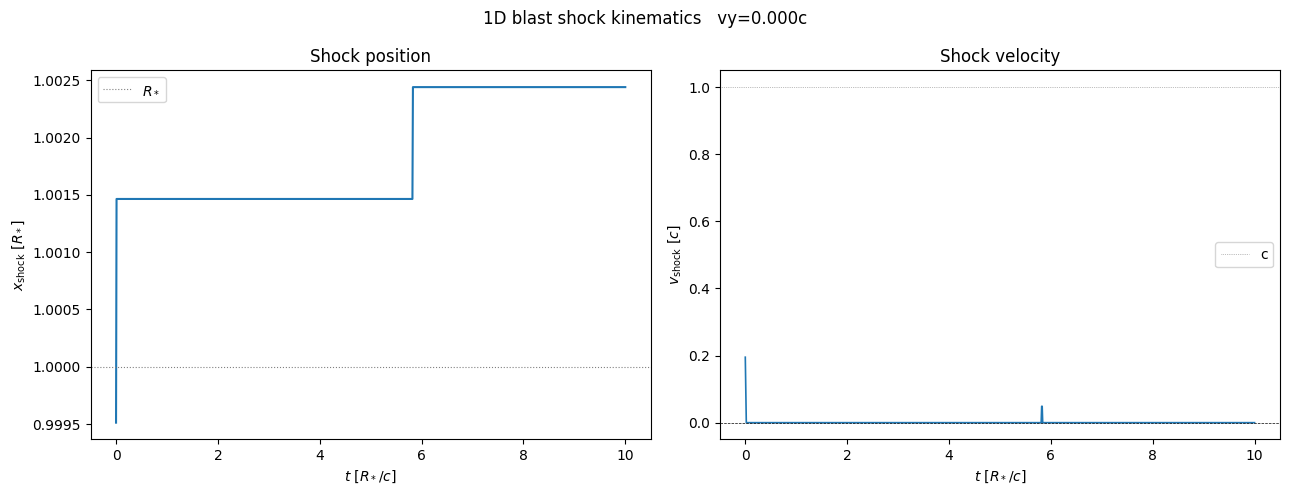

Shock breakthrough at t = 0.010009765625


In [9]:
PEAK_HEIGHT = 100.0
PEAK_DIST   = 10
R_MIN       = 0.05

shock_times = []
shock_radii = []

for ds in ts:
    t = float(ds.current_time)
    d = get_profile(ds)
    x = d['x']
    S = d['entropy']
    mask = (S > 0) & np.isfinite(S)

    if mask.sum() < 4:
        shock_times.append(t); shock_radii.append(np.nan)
        continue

    x_m   = x[mask]
    logS  = np.log10(S[mask])
    dlogS = np.abs(np.gradient(logS, x_m))
    peaks, _ = find_peaks(dlogS, height=PEAK_HEIGHT, distance=PEAK_DIST)
    valid = [x_m[p] for p in peaks if x_m[p] > R_MIN]
    shock_times.append(t)
    shock_radii.append(max(valid) if valid else np.nan)

shock_times = np.array(shock_times)
shock_radii = np.array(shock_radii)
v_shock = np.gradient(shock_radii, shock_times)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(shock_times, shock_radii, lw=1.5)
ax1.axhline(star_radius, color='grey', ls=':', lw=0.8, label='$R_*$')
ax1.set_xlabel(r'$t\ [R_*/c]$'); ax1.set_ylabel(r'$x_{\rm shock}\ [R_*]$')
ax1.set_title('Shock position'); ax1.legend()

ax2.plot(shock_times, v_shock, lw=1.2)
ax2.axhline(0, color='k', lw=0.5, ls='--')
ax2.axhline(1, color='grey', lw=0.5, ls=':', label='c')
ax2.set_xlabel(r'$t\ [R_*/c]$'); ax2.set_ylabel(r'$v_{\rm shock}\ [c]$')
ax2.set_title('Shock velocity'); ax2.legend()

fig.suptitle(f'1D blast shock kinematics   vy={vy_bulk:.3f}c')
plt.tight_layout(); plt.show()

bt = np.where(shock_radii >= star_radius)[0]
print('Shock breakthrough at t =', shock_times[bt[0]] if len(bt) else 'not yet')


In [10]:
frames_dir = Path('/scratch/aripoll/athena_out/frames_1d')
frames_dir.mkdir(parents=True, exist_ok=True)

S_samples, G_samples = [], []
for ds in ts[::max(1, len(ts)//20)]:
    d = get_profile(ds)
    ok = d['entropy'] > 0
    S_samples.extend(d['entropy'][ok].tolist())
    G_samples.extend(d['lorentz_gamma'].tolist())
S_lo = np.nanpercentile(S_samples, 1)
S_hi = np.nanpercentile(S_samples, 99)
G_hi = np.nanpercentile(G_samples, 99) * 1.1

for i, ds in enumerate(ts):
    t = float(ds.current_time)
    d = get_profile(ds)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0,0].semilogy(d['x'], d['rho'])
    axes[0,0].semilogy(r_poly, rho_poly, 'k--', lw=0.7)
    axes[0,0].set_ylabel(r'$\rho$')

    axes[0,1].semilogy(d['x'], d['press'])
    axes[0,1].semilogy(r_poly, P_poly, 'k--', lw=0.7)
    axes[0,1].set_ylabel(r'$P$')

    axes[1,0].semilogy(d['x'], np.clip(d['entropy'], 1e-40, None))
    axes[1,0].semilogy(r_poly, S_poly, 'k--', lw=0.7)
    axes[1,0].set_ylim(S_lo * 0.1, S_hi * 10)
    axes[1,0].set_ylabel(r'$S = P/\rho^\gamma$')

    axes[1,1].plot(d['x'], d['lorentz_gamma'])
    axes[1,1].set_ylim(0, G_hi)
    axes[1,1].set_ylabel(r'$\Gamma$')

    for ax in axes.flatten():
        ax.set_xlabel(r'$x\ [R_*]$')
        ax.axvline(star_radius, color='grey', ls=':', lw=0.8)
        ax.axvline(bomb_radius, color='red',  ls='--', lw=0.6)
        if i < len(shock_radii) and not np.isnan(shock_radii[i]):
            ax.axvline(shock_radii[i], color='cyan', ls='-', lw=0.9, alpha=0.8)

    fig.suptitle(f'1D blast   t={t:.3f} R*/c   vy={vy_bulk:.3f}c Gam_y={Gam_y:.2f}   bomb x{bomb_p_ratio:.0e}')
    plt.tight_layout()
    fig.savefig(frames_dir / f'frame_{i:05d}.png', dpi=150)
    plt.close(fig)

print(f'Wrote {len(ts)} frames to {frames_dir}')


yt : [WARNING  ] 2026-05-28 15:01:44,280 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 15:01:44,280 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 15:01:44,280 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 15:01:44,281 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 15:01:44,302 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-28 15:01:44,303 Parameters: domain_dimensions         = [2048    1    1]
yt : [INFO     ] 2026-05-28 15:01:44,303 Parameters: domain_left_edge          = [ 0.  -0.5 -0.5]
yt : [INFO     ] 2026-05-28 15:01:44,303 Parameters: domain_right_edge         = [2.  0.5 0.5]
yt : [INFO     ] 2026-05-28 15:01:44,304 Parameters: cosmological_simulation   = 0


yt : [WARNING  ] 2026-05-28 15:01:44,404 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 15:01:44,404 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 15:01:44,404 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 15:01:44,404 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 15:01:44,426 Parameters: current_time              = 0.500244140625
yt : [INFO     ] 2026-05-28 15:01:44,426 Parameters: domain_dimensions         = [2048    1    1]
yt : [INFO     ] 2026-05-28 15:01:44,427 Parameters: domain_left_edge          = [ 0.  -0.5 -0.5]
yt : [INFO     ] 2026-05-28 15:01:44,427 Parameters: domain_right_edge         = [2.  0.5 0.5]
yt : [INFO     ] 2026-05-28 15:01:44,427 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-05-28 15:01:44,531 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-28 15:01:44,532 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-28 15:01:44,532 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-28 15:01:44,533 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-28 15:0

Wrote 1001 frames to /scratch/aripoll/athena_out/frames_1d


In [11]:
from IPython.display import Video, display

mp4_path = '/scratch/aripoll/athena/1d_blast.mp4'
subprocess.run([
    'ffmpeg', '-y',
    '-framerate', '24',
    '-i', str(frames_dir / 'frame_%05d.png'),
    '-c:v', 'libx264',
    '-pix_fmt', 'yuv420p',
    '-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2',
    mp4_path
], check=True)

display(Video(mp4_path, embed=True))


ffmpeg version 4.4.4 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 12 (Gentoo 12.3.1_p20230526 p2)
  configuration: --prefix=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr --libdir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/lib64 --shlibdir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/lib64 --docdir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/share/doc/ffmpeg-4.4.4-r3/html --mandir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/share/man --enable-shared --cc=x86_64-pc-linux-gnu-gcc --cxx=x86_64-pc-linux-gnu-g++ --ar=x86_64-pc-linux-gnu-ar --nm=x86_64-pc-linux-gnu-nm --strip=x86_64-pc-linux-gnu-strip --ranlib=x86_64-pc-linux-gnu-ranlib --pkg-config=x86_64-pc-linux-gnu-pkg-config --optflags='-O2 -pipe -march=x86-64-v3 -O2 -ftree-vectorize -fno-math-errno -pipe -O2 -pipe' --disable-static --enable-avfilter --enable-avresample --disable-stripping --disable-optimizations --disable-libcelt --disable-indev=v4l2 --disable-outdev